### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

2026-02-27 13:14:50.275619: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-27 13:14:50.275671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-27 13:14:50.276671: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-27 13:14:50.282739: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Step 2: Load Data

In [4]:
labels = pd.read_csv('/workspace/data/datasets_dog_breed_classification/labels.csv')

In [5]:
train_path = '/workspace/data/datasets_dog_breed_classification/train'
test_path = '/workspace/data/datasets_dog_breed_classification/test'

In [6]:
labels.shape

(10222, 2)

In [7]:
labels['id'] = labels['id'].map(lambda x: x+'.jpg')

In [8]:
labels.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07.jpg,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97.jpg,dingo
2,001cdf01b096e06d78e9e5112d419397.jpg,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d.jpg,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62.jpg,golden_retriever


### Step 3: Preparing Data

#### Build Data

In [9]:
gen = ImageDataGenerator(
    rescale = 1./255,
    horizontal_flip=True,
    validation_split=0.2
)

In [10]:
train_generator = gen.flow_from_dataframe(
    labels,
    directory=train_path,
    x_col='id',
    y_col='breed',
    subset='training',
    color_mode='rgb',
    target_size=(331, 331),
    class_mode='categorical',
    batch_size=20,
    shuffle=True,
    seed=42
)

Found 8178 validated image filenames belonging to 120 classes.


In [11]:
validation_generator = gen.flow_from_dataframe(
    labels,
    directory=train_path,
    x_col='id',
    y_col='breed',
    subset='validation',
    color_mode='rgb',
    target_size=(331, 331),
    class_mode='categorical',
    batch_size=20,
    shuffle=True,
    seed=42
)

Found 2044 validated image filenames belonging to 120 classes.


#### Show Data

In [12]:
x, y = next(train_generator)

In [13]:
x.shape, y.shape

((20, 331, 331, 3), (20, 120))

In [14]:
class_index = train_generator.class_indices
class_name = list(class_index.keys())

In [19]:
def plot_images(img, labels):
    plt.figure(figsize=(15, 10))
    for i in range(20):
        plt.subplot(5, 4, i+1)
        plt.imshow(img[i])
        plt.title(class_name[np.argmax(labels[i])])
        plt.axis('off')

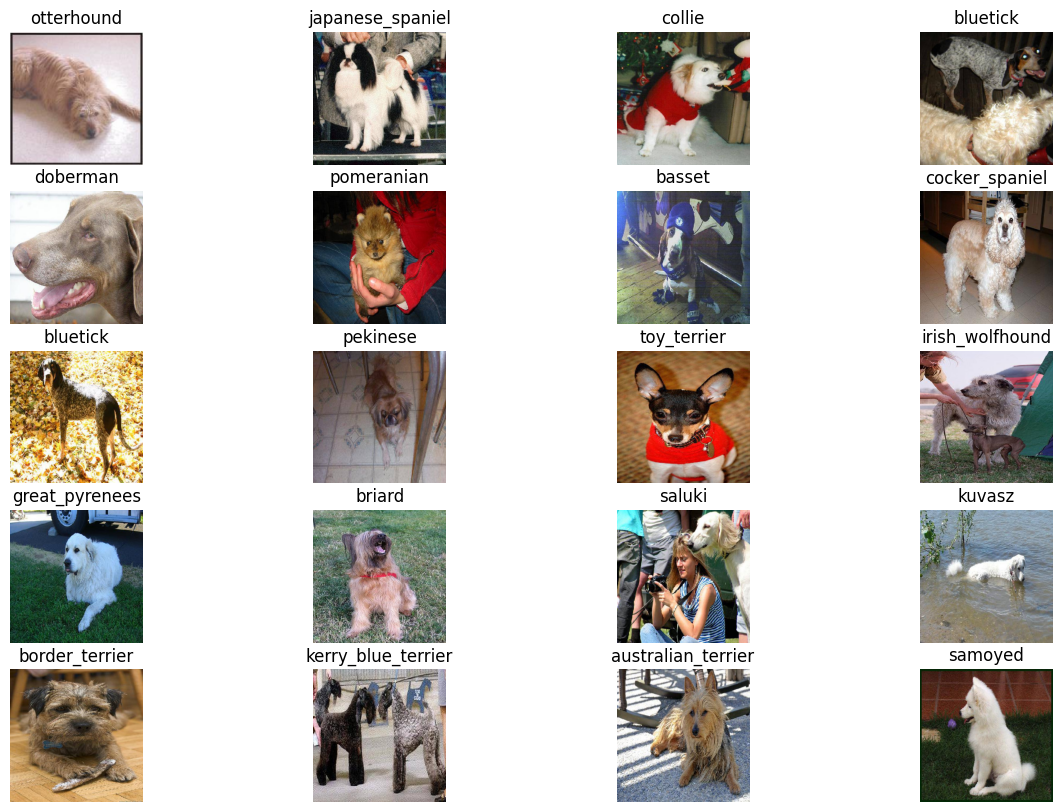

In [20]:
plot_images(x, y)

### Step 4: Model Development

In [21]:
base_model = applications.InceptionResNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(331, 331, 3)
)

2026-02-27 13:23:27.343399: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1054 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


In [22]:
base_model.trainable = False

In [26]:
inputs = layers.Input(shape=(331, 331, 3))
x = base_model(inputs)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(120, activation='softmax')(x)

In [27]:
model = Model(inputs, outputs)

In [28]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 331, 331, 3)]     0         
                                                                 
 inception_resnet_v2 (Funct  (None, 9, 9, 1536)        54336736  
 ional)                                                          
                                                                 
 batch_normalization_204 (B  (None, 9, 9, 1536)        6144      
 atchNormalization)                                              
                                                                 
 global_average_pooling2d_1  (None, 1536)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_4 (Dense)             (None, 512)               786944    
                                                           

In [29]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

In [30]:
early = EarlyStopping(
    patience=10,
    min_delta=0.001,
    restore_best_weights=True
)

In [31]:
batch_size=20

In [32]:
STEP_SIZE_TRAIN = train_generator.n // train_generator.batch_size
STEP_SIZE_VALID = validation_generator.n // validation_generator.batch_size

In [33]:
history = model.fit(
    train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=validation_generator,
    validation_steps=STEP_SIZE_VALID,
    epochs=25,
    callbacks=[early]
)

Epoch 1/25


2026-02-27 13:24:37.013052: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-02-27 13:24:37.554187: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.53GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-27 13:24:37.715793: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.53GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-27 13:24:39.761480: I external/local_xla/xla/service/service.cc:168] XLA service 0x7515893bd850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-27 13:24:39.761529: I external/local_xla/xla/service/service.

 33/408 [=>............................] - ETA: 28s - loss: 4.0759 - accuracy: 0.1758

2026-02-27 13:24:43.260169: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.48GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-27 13:24:43.408237: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.48GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


408/408 [==============================] - 52s 105ms/step - loss: 1.1835 - accuracy: 0.7395 - val_loss: 0.4003 - val_accuracy: 0.8907
Epoch 2/25
408/408 [==============================] - 38s 93ms/step - loss: 0.5401 - accuracy: 0.8655 - val_loss: 0.4163 - val_accuracy: 0.8902
Epoch 3/25
408/408 [==============================] - 38s 94ms/step - loss: 0.4770 - accuracy: 0.8736 - val_loss: 0.4123 - val_accuracy: 0.9044
Epoch 4/25
408/408 [==============================] - 38s 93ms/step - loss: 0.4451 - accuracy: 0.8794 - val_loss: 0.4447 - val_accuracy: 0.8902
Epoch 5/25
408/408 [==============================] - 38s 93ms/step - loss: 0.3880 - accuracy: 0.8991 - val_loss: 0.4454 - val_accuracy: 0.8990
Epoch 6/25
408/408 [==============================] - 38s 94ms/step - loss: 0.3458 - accuracy: 0.9033 - val_loss: 0.4149 - val_accuracy: 0.9020
Epoch 7/25
408/408 [==============================] - 38s 94ms/step - loss: 0.3455 - accuracy: 0.9044 - val_loss: 0.4082 - val_accuracy: 0.8995
Ep

In [34]:
model.save("/workspace/data/datasets_dog_breed_classification/Model.h5")

In [35]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
plt.figure(figsize=(10, 16))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title(f'Training and Validation Accuracy. Train Accuracy: {round(acc[-1], 3)}, Validation Accuracy: {round(val_acc[-1], 3)}')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title(f'Training and Validation Loss. \nTrain Loss: {round(loss[-1], 3)}, Validation Loss: {str(val_loss[-1])}')